### 試著挑一個最準的模型出來

In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report  
import matplotlib.pyplot as plt
from scipy.stats import mode
from collections import Counter
import itertools
from dateutil.relativedelta import relativedelta
from datetime import datetime, timedelta


In [10]:
import csv

# 讀入文章集
content = list() #用串列預備儲存所有內容

f = open('bullishnews_ok.csv', newline='', encoding='utf-8') #開檔 
rows = csv.reader(f, delimiter=',') #讀檔
for row in rows: 
  content.append(row[0])
f.close()

f = open('bearishnews_ok.csv', newline='', encoding='utf-8') #開檔 
rows = csv.reader(f, delimiter=',') #讀檔
for row in rows:
  content.append(row[0])
f.close()

In [ ]:
y = [] #用以儲存已知類別
for i in range(1003): #已知前1003篇為漲，標記為看漲 (此為取巧權宜作法)
  y.append(['看漲'])
for i in range(1145): #已知後1145篇為跌停，標記為看跌
  y.append(['看跌'])
y=np.ravel(y) #轉換成array避免警告訊息
pd.DataFrame(y) #將y印出做觀察

In [21]:
# 寫一個函數可以跑出特定字數的X

# 從自己算出來的tf-idf的上漲下跌文字集中取

def give_X_tfidf(use_words):

  termset = {}

  with open('bullish_allwords.csv', newline='', encoding='utf-8') as f:
    rows = csv.reader(f, delimiter=',')
    for row in itertools.islice(rows, use_words):
      if row[0] not in termset:
        termset[row[0]] = 0
  f.close()

  with open('bearish_allwords.csv', newline='', encoding='utf-8') as f:
    rows = csv.reader(f, delimiter=',')
    for row in itertools.islice(rows, use_words):
      if row[0] not in termset:
        termset[row[0]] = 0
      else: del termset[row[0]]
  f.close()

  no=0 #幫詞彙編號
  for term in termset:
    termset[term] = no
    no += 1
    
  from sklearn.feature_extraction.text import TfidfVectorizer
  vectorizer = TfidfVectorizer(vocabulary=termset,use_idf=True) #用給定的termset建構向量，並使用idf加權

  X = vectorizer.fit_transform(content) #用給定的文件集做計算
  
  print("\n")
  print(f'以下是使用詞彙數= {use_words} 的結果')
  
  return X

In [15]:
# 寫一個函數可以跑出特定字數的X

# 從tf和df的上漲下跌文字集中取 這有四個文件

def give_X_tf_df(use_words):

  termset = {}

  with open('bullish_tf_words.csv', newline='', encoding='utf-8') as f:
    rows = csv.reader(f, delimiter=',')
    for row in itertools.islice(rows, use_words):
      if row[0] not in termset:
        termset[row[0]] = 0
  f.close()

  with open('bullish_df_words.csv', newline='', encoding='utf-8') as f:
    rows = csv.reader(f, delimiter=',')
    for row in itertools.islice(rows, use_words):
      if row[0] not in termset:
        termset[row[0]] = 0
      else: del termset[row[0]]
  f.close()

  with open('bearish_tf_words.csv', newline='', encoding='utf-8') as f:
    rows = csv.reader(f, delimiter=',')
    for row in itertools.islice(rows, use_words):
      if row[0] not in termset:
        termset[row[0]] = 0
      else: del termset[row[0]]
  f.close()

  with open('bearish_df_words.csv', newline='', encoding='utf-8') as f:
    rows = csv.reader(f, delimiter=',')
    for row in itertools.islice(rows, use_words):
      if row[0] not in termset:
        termset[row[0]] = 0
      else: del termset[row[0]]
  f.close()

  no=0 #幫詞彙編號
  for term in termset:
    termset[term] = no
    no += 1
    
  from sklearn.feature_extraction.text import TfidfVectorizer
  vectorizer = TfidfVectorizer(vocabulary=termset,use_idf=True) #用給定的termset建構向量，並使用idf加權

  X2 = vectorizer.fit_transform(content) #用給定的文件集做計算
  
  print("\n")
  print(f'以下是使用詞彙數= {use_words} 的結果')
  
  return X2

In [18]:
X2 = give_X_tf_df(500)
X2

c:\Users\jason\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\feature_extraction\text.py:1381: UserWarning: Upper case characters found in vocabulary while 'lowercase' is True. These entries will not be matched with any documents
  warnings.warn(




以下是使用詞彙數= 500 的結果


<2148x100 sparse matrix of type '<class 'numpy.float64'>'
	with 14597 stored elements in Compressed Sparse Row format>

In [13]:
# 寫一個函數可以對不同testsize訓練

def train_diffsize(X,y,size):

    print(f'  test_size= {size} ')

    # 數據準備
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=size, random_state=69)

    # 模型訓練
    models = {
        'NB': MultinomialNB(),
        'SVC': SVC(random_state=69),
        'KNN': KNeighborsClassifier(),
        'Decision Tree': DecisionTreeClassifier(random_state=69),
        'Random Forest': RandomForestClassifier(random_state=69),
        'MLP': MLPClassifier(random_state=69, max_iter=1000)
    }

    # 預測和評估
    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        results[name] = {'Accuracy': acc, 'Confusion Matrix': confusion_matrix(y_test, y_pred)}
        print(f'{name} Model Accuracy: {acc:.2f}')

    # 建立投票模型
    # 將各模型對測試集的預測結果收集起來
    predictions = [model.predict(X_test) for model in models.values()]  # list of arrays
    predictions = np.array(predictions).T  # shape: (n_samples, n_models)

    # 對每一個樣本投票，找出出現次數最多的類別
    vote_predictions = []
    for row in predictions:
        # row 形如 ["class1", "class2", ...]，用 Counter 找最多的
        most_common_label = Counter(row).most_common(1)[0][0]
        vote_predictions.append(most_common_label)

    vote_predictions = np.array(vote_predictions)

    # 評估投票後的結果
    vote_accuracy = accuracy_score(y_test, vote_predictions)
    vote_confusion_matrix = confusion_matrix(y_test, vote_predictions)
    results['voting'] = {'Accuracy': vote_accuracy, 'Confusion Matrix': vote_confusion_matrix}
    print(f'Majority Voting Accuracy: {vote_accuracy:.2f}')

    return results

In [ ]:
# 測試各種詞彙量和測試大小 - 用tf&df取詞 (不好)

usewordnum = [500, 1000, 2000]
usesize = [0.1, 0.2, 0.3]

for num in usewordnum:
    X = give_X_tf_df(num)

    for size in usesize:
        train_diffsize(X, y, size)

In [ ]:
# 測試各種詞彙量和測試大小 - 用tfidf取詞
usewordnum = [1500, 2000]
usesize = [0.1, 0.2, 0.3]

best_reselt = {}

for num in usewordnum:
    X = give_X_tfidf(num)

    for size in usesize:
        result = train_diffsize(X, y, size)
        best_model = max(result, key=lambda k: result[k]['Accuracy'])
        best_acc   = result[best_model]['Accuracy']
        print(f"Best model: {best_model}, Accuracy = {best_acc:.4f}")

### 發現用自訂的tfidf詞彙集取2000個是相對最好的做法
用tf加df來取幾乎沒能超過0.67 不太行

c:\Users\jason\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\feature_extraction\text.py:1381: UserWarning: Upper case characters found in vocabulary while 'lowercase' is True. These entries will not be matched with any documents
  warnings.warn(




以下是使用詞彙數= 2000 的結果
  test_size= 0.2 
NB Model Accuracy: 0.71
SVC Model Accuracy: 0.75
KNN Model Accuracy: 0.63
Decision Tree Model Accuracy: 0.64
Random Forest Model Accuracy: 0.67
MLP Model Accuracy: 0.72
Majority Voting Accuracy: 0.73
Best model: SVC, Accuracy = 0.75


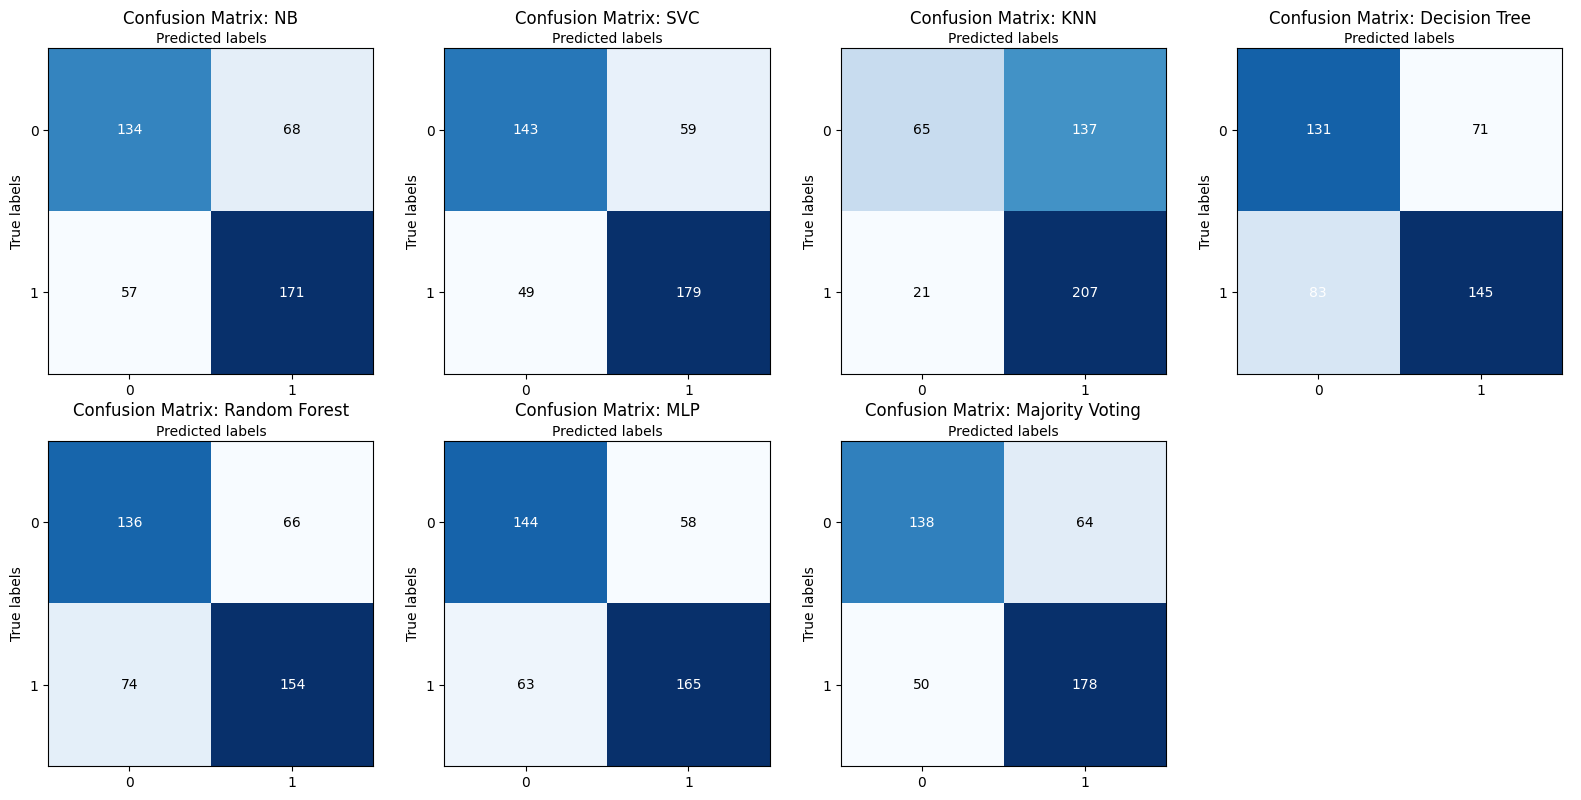

In [29]:
X = give_X_tfidf(num)
result = train_diffsize(X, y, 0.2)

best_model = max(result, key=lambda k: result[k]['Accuracy'])
best_acc   = result[best_model]['Accuracy']
print(f"Best model: {best_model}, Accuracy = {best_acc:.2f}")

models = list(result.keys())
# 建立 2x4 的子圖
fig, axs = plt.subplots(2, 4, figsize=(16, 8))

# 繪製前四個模型在第一列
for idx, model_name in enumerate(models[:4]):
    ax = axs[0, idx]
    cm = result[model_name]['Confusion Matrix']
    im = ax.imshow(cm, cmap=plt.cm.Blues)
    ax.set_title(f'Confusion Matrix: {model_name}')
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.xaxis.set_label_position('top')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    # 標註數值，超過一半用白色，否則用黑色
    for (i, j), val in np.ndenumerate(cm):
        color = 'white' if val > cm.max() / 2 else 'black'
        ax.text(j, i, val, ha='center', va='center', color=color)

# 第二列：繪製剩下三個模型，最後一格隱藏
for idx, model_name in enumerate(models[4:]):
    ax = axs[1, idx]
    cm = result[model_name]['Confusion Matrix']
    im = ax.imshow(cm, cmap=plt.cm.Blues)
    title_name = 'Majority Voting' if model_name == 'voting' else model_name
    ax.set_title(f'Confusion Matrix: {title_name}')
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.xaxis.set_label_position('top')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    for (i, j), val in np.ndenumerate(cm):
        color = 'white' if val > cm.max() / 2 else 'black'
        ax.text(j, i, val, ha='center', va='center', color=color)

# 隱藏最後一個空白子圖
axs[1, 3].axis('off')

plt.tight_layout()
plt.show()


### 開始試圖進行回測

In [79]:
from scipy.sparse import vstack

def moving_backtest(news_data, trans_data):

    start_date = news_data['post_time'].min()
    end_date = news_data['post_time'].max()

    current_date = start_date + timedelta(days=30)
    pred_df = pd.DataFrame({'date': pd.Series(), 'y_test': pd.Series(), 'y_pred': pd.Series()})

    while current_date + timedelta(days=1) <= end_date:
        train_start = current_date - timedelta(days=30)   # D 日往前 30 天
        train_end   = current_date - timedelta(days=1)    # 到 D 日的前一天
        test_start  = current_date                        # 測試特徵 X 用 D 日
        #test_end    = current_date                       

        X_train_list = news_data[(pd.to_datetime(news_data['post_time']).dt.date >= train_start) & (pd.to_datetime(news_data['post_time']).dt.date <= train_end)]['vector'].tolist()
        y_train = news_data[(pd.to_datetime(news_data['post_time']).dt.date >= train_start) & (pd.to_datetime(news_data['post_time']).dt.date <= train_end)]['Change'].values
        X_test_list = news_data[(pd.to_datetime(news_data['post_time']).dt.date  == test_start)]['vector'].tolist()
        y_test = news_data[(pd.to_datetime(news_data['post_time']).dt.date  == test_start)]['Change'].values
        
        # 如果某一天没有新闻或交易，就跳过
        if len(X_train_list) == 0 or len(X_test_list) == 0 or len(y_test) == 0:
            current_date += timedelta(days=1)
            continue

        # 把列表中的 row‑vectors vstack 回一个 (n_samples, n_features) 稀疏矩阵
        X_train = vstack(X_train_list)
        X_test  = vstack(X_test_list)

        model = SVC(random_state=69)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        # 投票決定單日方向
        up   = int((y_pred ==  1).sum())
        down = int((y_pred == -1).sum())
        if up > down:
            action = 1
        elif down > up:
            action = -1
        else:
            action = 0

        actual_series = trans_data.loc[pd.to_datetime(trans_data['date']).dt.date == current_date,'Change']
        if actual_series.empty:
            # 如果找不到标签就跳过
            current_date += timedelta(days=1)
            continue

        actual = actual_series.iloc[0]

        pred_df.loc[len(pred_df)] = [current_date, actual, action]

        acc = accuracy_score(y_test, y_pred)
        #print(f'{current_date} accuracy: {acc}')

        current_date += timedelta(days=1)
    
    return pred_df
    

In [73]:
news1 = pd.read_csv('bullish_news_ft.csv')
news2 = pd.read_csv('bearish_news_ft.csv')
Ft_trans = pd.read_csv('FT_all_trans.csv')
Ft_news = pd.concat([news1, news2], ignore_index=True)

Ft_news['contents'] = Ft_news['title'] + ' ' + Ft_news['content']
# （選擇性）如果不需要原本的 title, content，可以把它們刪掉
Ft_news = Ft_news.drop(columns=['title', 'content'])

Ft_news['post_time'] = pd.to_datetime(Ft_news['post_time']).dt.date

termset = {}

with open('bullish_allwords.csv', newline='', encoding='utf-8') as f:
  rows = csv.reader(f, delimiter=',')
  for row in itertools.islice(rows, 2000):
    if row[0] not in termset:
      termset[row[0]] = 0
f.close()

with open('bearish_allwords.csv', newline='', encoding='utf-8') as f:
  rows = csv.reader(f, delimiter=',')
  for row in itertools.islice(rows, 2000):
    if row[0] not in termset:
      termset[row[0]] = 0
    else: del termset[row[0]]
f.close()

no=0 #幫詞彙編號
for term in termset:
  termset[term] = no
  no += 1

from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(vocabulary=termset,use_idf=True) #用給定的termset建構向量，並使用idf加權

content = Ft_news['contents']
X = vectorizer.fit_transform(content) #用給定的文件集做計算

Ft_news['vector'] = [X.getrow(i) for i in range(X.shape[0])]


c:\Users\jason\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\feature_extraction\text.py:1381: UserWarning: Upper case characters found in vocabulary while 'lowercase' is True. These entries will not be matched with any documents
  warnings.warn(


In [81]:
pred_df = moving_backtest(Ft_news, Ft_trans)

# 假設你的 DataFrame 是 pred_df
df = pred_df.copy()

# 1. 轉成 datetime 並加上月份欄
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')

# 2. 排除沒有出手 (y_pred == 0)
df_trade = df[df['y_pred'] != 0].copy()

# 3. 計算是否猜對
df_trade['correct'] = df_trade['y_test'] == df_trade['y_pred']

# 4. 按月彙總：總出手天數 & 猜對天數、計算準確率（%）
monthly = (
    df_trade
    .groupby('month')
    .agg(
        trade_days=('correct', 'size'),
        correct_days=('correct', 'sum')
    )
)
monthly['accuracy_%'] = monthly['correct_days'] / monthly['trade_days'] * 100

print(monthly.reset_index())

      month  trade_days  correct_days  accuracy_%
0   2023-02           9             3   33.333333
1   2023-03          11             6   54.545455
2   2023-04          11             6   54.545455
3   2023-05          18            11   61.111111
4   2023-06          11             5   45.454545
5   2023-07          15             8   53.333333
6   2023-08          15             9   60.000000
7   2023-09          12             8   66.666667
8   2023-10          10             6   60.000000
9   2023-11          10             7   70.000000
10  2023-12          14             7   50.000000
11  2024-01          14             5   35.714286
12  2024-02           7             2   28.571429
13  2024-03          14             6   42.857143
14  2024-04          10             4   40.000000
15  2024-05          13             7   53.846154
16  2024-06          11             4   36.363636
17  2024-07          14             8   57.142857
18  2024-08          16            10   62.500000
